In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import vstack, hstack, csr_matrix
from sklearn.svm import LinearSVC

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')
nltk.download('punkt_tab')
nltk.download('tagsets_json')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_d

True

In [ ]:
# Loading data into df

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DS3010/Phishing_Email.csv')
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
# Removing rows with missing text & one row thats 17 million characters long for some reason

df = df.dropna(subset = ['Email Text'])
df = df[df['Email Text'].str.len() < 1_000_000]

In [ ]:
# Making sure there are enough of both kinds of emails to get a good sample

real_count = len(df[df['Email Type'] == 'Safe Email'])
phishing_count = len(df[df['Email Type'] == 'Phishing Email'])
print(real_count)
print(phishing_count)

11321
7312


In [ ]:
# Creating Lemmatized text column (takes a few minutes to run)

def lemmatize(text):
    tokens = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(token.lower()) for token in tokens]
    return " ".join(lemmas)

df["Email_Text_Lemmatized"] = df["Email Text"].apply(lemmatize_and_clean)

In [ ]:
# Calculate lexical diversity of each email

def lexical_diversity(tokens):
    return 1.0*len(set(tokens))/len(tokens)

ld_list = []

for row in df.iterrows():

  text = row[1]['Email Text']
  try:
    tokens = nltk.word_tokenize(text)
    ld = lexical_diversity(tokens)
    ld_list.append(ld)
    # print(ld)
  except Exception as e: # if there's an error in tokenizing the email
    ld_list.append(0) # use 0 as lexical diversity instead of None to avoid future problems


# Adding the new field to the data frame
df['Lexical Diversity'] = ld_list

In [ ]:
# Calculate sentiment score of each email

from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

ss_list = []

for row in df.iterrows():
  try:
    text = row[1]['Email Text'][:5000]
    score = analyzer.polarity_scores(text)['compound']
    ss_list.append(score)
  except Exception as e: # if there's an error
    ss_list.append(0) # use 0 as sentiment for unscored emails

df['Sentiment Score'] = ss_list

In [ ]:
le_list = []

for row in df.iterrows():
  try:
    text = row[1]['Email Text']
  except Exception as e: # if there's an error
    ss_list.append(0) # use 0 as sentiment for unscored emails

In [ ]:
df['Lexical Diversity'] = ld_list
df['Sentiment Score'] = ss_list

df.head()

,Unnamed: 0,Email Text,Email Type,Lexical Diversity,Sentiment Score
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0.521739,0.9798
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0.659341,0.4329
2,2,re : equistar deal tickets are you still avail...,Safe Email,0.363934,0.8591
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,0.767241,0.9640
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,0.714286,0.0534


In [ ]:
# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df['Email Text'] = df['Email Text'].apply(
    lambda text: ' '.join(
        [word for word in re.findall(r'\b\w+\b', text.lower()) if word not in stop_words]
    )
)

# remove
df['Email_Text_Lemmatized'] = df['Email_Text_Lemmatized'].apply(
    lambda text: ' '.join(
        [word for word in re.findall(r'\b\w+\b', text.lower()) if word not in stop_words]
    )
)

In [ ]:
# Vectorizing text using HashingVectorizer because my laptop was running out of memory with TF-IDF :(
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=2**18, alternate_sign=False, norm='l2', lowercase=True)

# Transforming text
df['hash_sparse'] = df['Email Text'].apply(
    lambda txt: hv.transform([txt])[0]
)

# Transforming lemmatized text
df['hash_sparse_lemmatized'] = df['Email_Text_Lemmatized'].apply(
    lambda txt: hv.transform([txt])[0]
)

Training accuracy: 0.988528109486113
Test accuracy: 0.9769251408639656


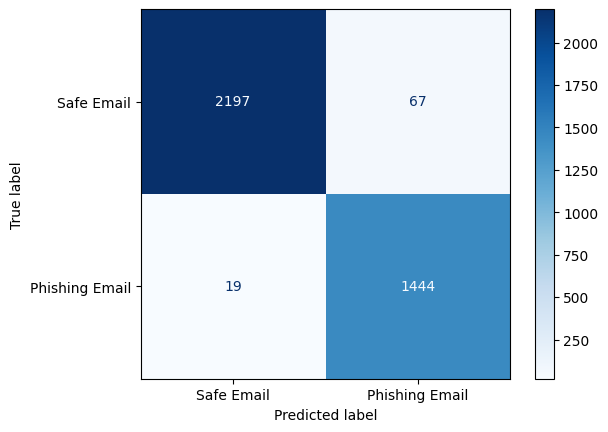

In [ ]:
# Training & evaluating model using only the HashingVectorizer data

X = vstack(df['hash_sparse'].values)
y = df['Email Type'].values

# Splitting data & stratifying the target variable so it isn't biased
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Using LinearSVC because it accepts sparse data (CSR Matrix)
model = LinearSVC()
model.fit(X_train, y_train)

# Predicting & evaluating the model
y_pred = model.predict(X_test)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
cm = confusion_matrix(y_test, y_pred)

# Displaying results for test data
print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

# Confusion matrix
desired_order = ['Safe Email', 'Phishing Email']
class_labels = ['Safe Email', 'Phishing Email']
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=desired_order,
    display_labels=class_labels,
    cmap="Blues"
)

Training accuracy: 0.988528109486113
Test accuracy: 0.9763885162328951


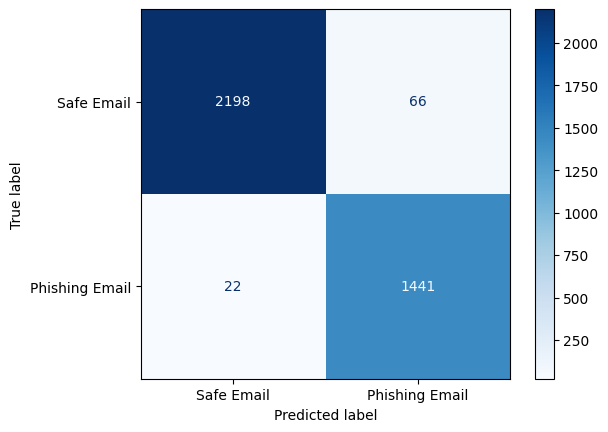

In [ ]:
# Training & evaluating model using vectrorized text + other features

X_text = vstack(df['hash_sparse'].values)
y = df['Email Type'].values

# Converting numeric features into a CSR matrix
numeric_vals = df[['Lexical Diversity','Sentiment Score']].values
X_num = csr_matrix(numeric_vals)

# Combining features together
X_full = hstack([X_text, X_num])

y = df['Email Type'].values

# Splitting data & stratifying the target variable so it isn't biased
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Using LinearSVC again because it accepts sparse data (CSR Matrix)
model = LinearSVC()
model.fit(X_train, y_train)

# Predicting & evaluating the model
y_pred = model.predict(X_test)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
cm = confusion_matrix(y_test, y_pred)

# Displaying results for test data
print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

# Confusion matrix
desired_order = ['Safe Email', 'Phishing Email']
class_labels = ['Safe Email', 'Phishing Email']
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=desired_order,
    display_labels=class_labels,
    cmap="Blues"
)

Training accuracy: 0.9875218033006843
Test accuracy: 0.9726321438154011


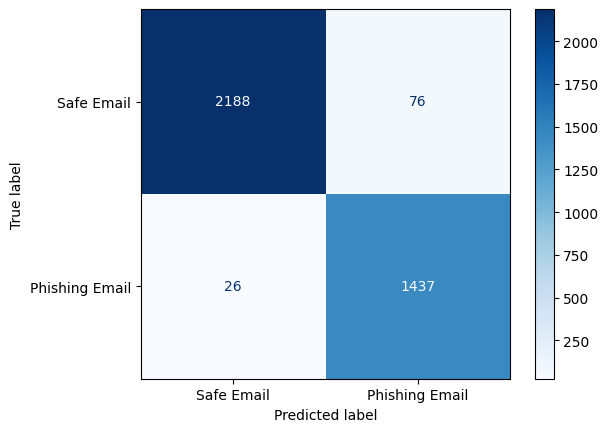

In [ ]:
# Training & evaluating model using only the lemmatized HashingVectorizer data

X = vstack(df['hash_sparse_lemmatized'].values)

# Splitting data & stratifying the target variable so it isn't biased
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Using LinearSVC because it accepts sparse data (CSR Matrix)
model = LinearSVC()
model.fit(X_train, y_train)

# Predicting & evaluating the model
y_pred = model.predict(X_test)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
cm = confusion_matrix(y_test, y_pred)

# Displaying results for test data
print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

# Confusion matrix
desired_order = ['Safe Email', 'Phishing Email']
class_labels = ['Safe Email', 'Phishing Email']
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=desired_order,
    display_labels=class_labels,
    cmap="Blues"
)